# 01. Basic Generation and Markets

This first model establishes the foundational mechanics of modeling an energy system in PyPSA. 

The objective is to model a standalone **10 MW Solar PV plant** operating in the DK1 bidding zone. The system will dispatch power to the Day-Ahead market to maximize revenue. Because PyPSA is fundamentally a *cost-minimization* solver, revenue is modeled as a negative cost.

## 🛠️ System Topology
1. **Buses:** A single primary electrical bus.
2. **Generators (Source):** A solar PV plant with a fixed capacity of 10 MW. The generation profile is constrained by the normalized Renewables.ninja weather data.
3. **Generators (Sink):** A secondary generator representing the grid connection. It is bounded with a maximum dispatch of 0 MW and a minimum of -1 p.u., forcing it to act strictly as a power sink. Its marginal cost is set to the Day-Ahead market price, meaning any consumed power (negative dispatch) results in a negative cost (revenue).

Whenever the market price is positive, the solver will push available solar energy into the grid sink to generate revenue. If the market price drops below zero, the grid sink shuts off, and the solver automatically curtails the solar generation to avoid financial penalties.

<img src="../assets/model_1.jpg" alt="Model 01 System Topology" width="800">

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force both dataframes to use this clean index
df_pv.index = perfect_index
df_price.index = perfect_index


df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)

## ⚙️ Technical Parameters

To maintain a clean separation between data and logic, all static technical and economic assumptions are centralized in a dictionary. This ensures parameters can be easily audited or modified for sensitivity analysis without altering the core network code.

In [2]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW      
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh 
    },
    'market_grid': {
        'p_nom': 10.0           # Maximum export capacity to the grid
    }
}

## 🏗️ Initializing the Network

In PyPSA, the `Network` object is the container for all physical and economic components. Since we are modeling a standalone system selling to the grid, we only need a single electrical bus.

In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add the single physical electrical bus
n.add("Bus", "electricity_bus")

Index(['electricity_bus'], dtype='object')

## ⚡ Adding Generators and Grid Connection

We will attach the solar PV plant to the electricity bus. To model the ability to sell power to the Day-Ahead market, we add a second `Generator` to represent the grid connection. 

By setting the grid generator's maximum dispatch to 0 and its minimum to -1, it acts strictly as a power sink. PyPSA calculates cost as `dispatch * marginal_cost`. Therefore, a negative dispatch multiplied by a positive market price results in a negative cost, successfully modeling market revenue.

In [4]:
# 1. Add the Solar PV generator
n.add("Generator", 
      "Solar_PV", 
      bus="electricity_bus", 
      p_nom=tech_param['solar_pv']['p_nom'], 
      p_max_pu=df_pv['capacity_factor'],    
      marginal_cost=tech_param['solar_pv']['marginal_cost']) 

# 2. Add the Grid Market Sink (Negative Generator)
n.add("Generator", 
      "Grid_Export", 
      bus="electricity_bus", 
      p_nom=tech_param['market_grid']['p_nom'],  
      p_min_pu=-1.0,                        # Allows it to consume up to 100% of p_nom
      p_max_pu=0.0,                         # Prevents it from generating power
      marginal_cost=df_price['price'])      # The actual market price

Index(['Grid_Export'], dtype='object')

## 🧠 Running the Optimization

With the single-bus topology and the negative-generator market sink defined, the network is passed to the solver. The solver will calculate the optimal dispatch strategy for all 8760 hours simultaneously to maximize revenue (minimize negative cost).

In [5]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Negative Revenue): €{n.objective:,.2f}")

Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00,  8.98it/s]
INFO:linopy.io: Writing time: 0.84s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 17520 primals, 43800 duals
Objective: -6.59e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Solver Status: ok
Total Objective Value (Negative Revenue): €-658,678.97


## 📊 Analyzing the Results

Because the grid export generator is bounded by a maximum of 0 MW, it acts strictly as a sink. The solver will export solar power to the grid during all hours where the day-ahead price is positive. 

The following calculations aggregate the total annual generation and market revenue for the entire year, followed by a visualization of the 8760-hour generation profile.

Total Annual Solar Production: 9,876.77 MWh
Total Annual Market Revenue: €658,678.97
----------------------------------------


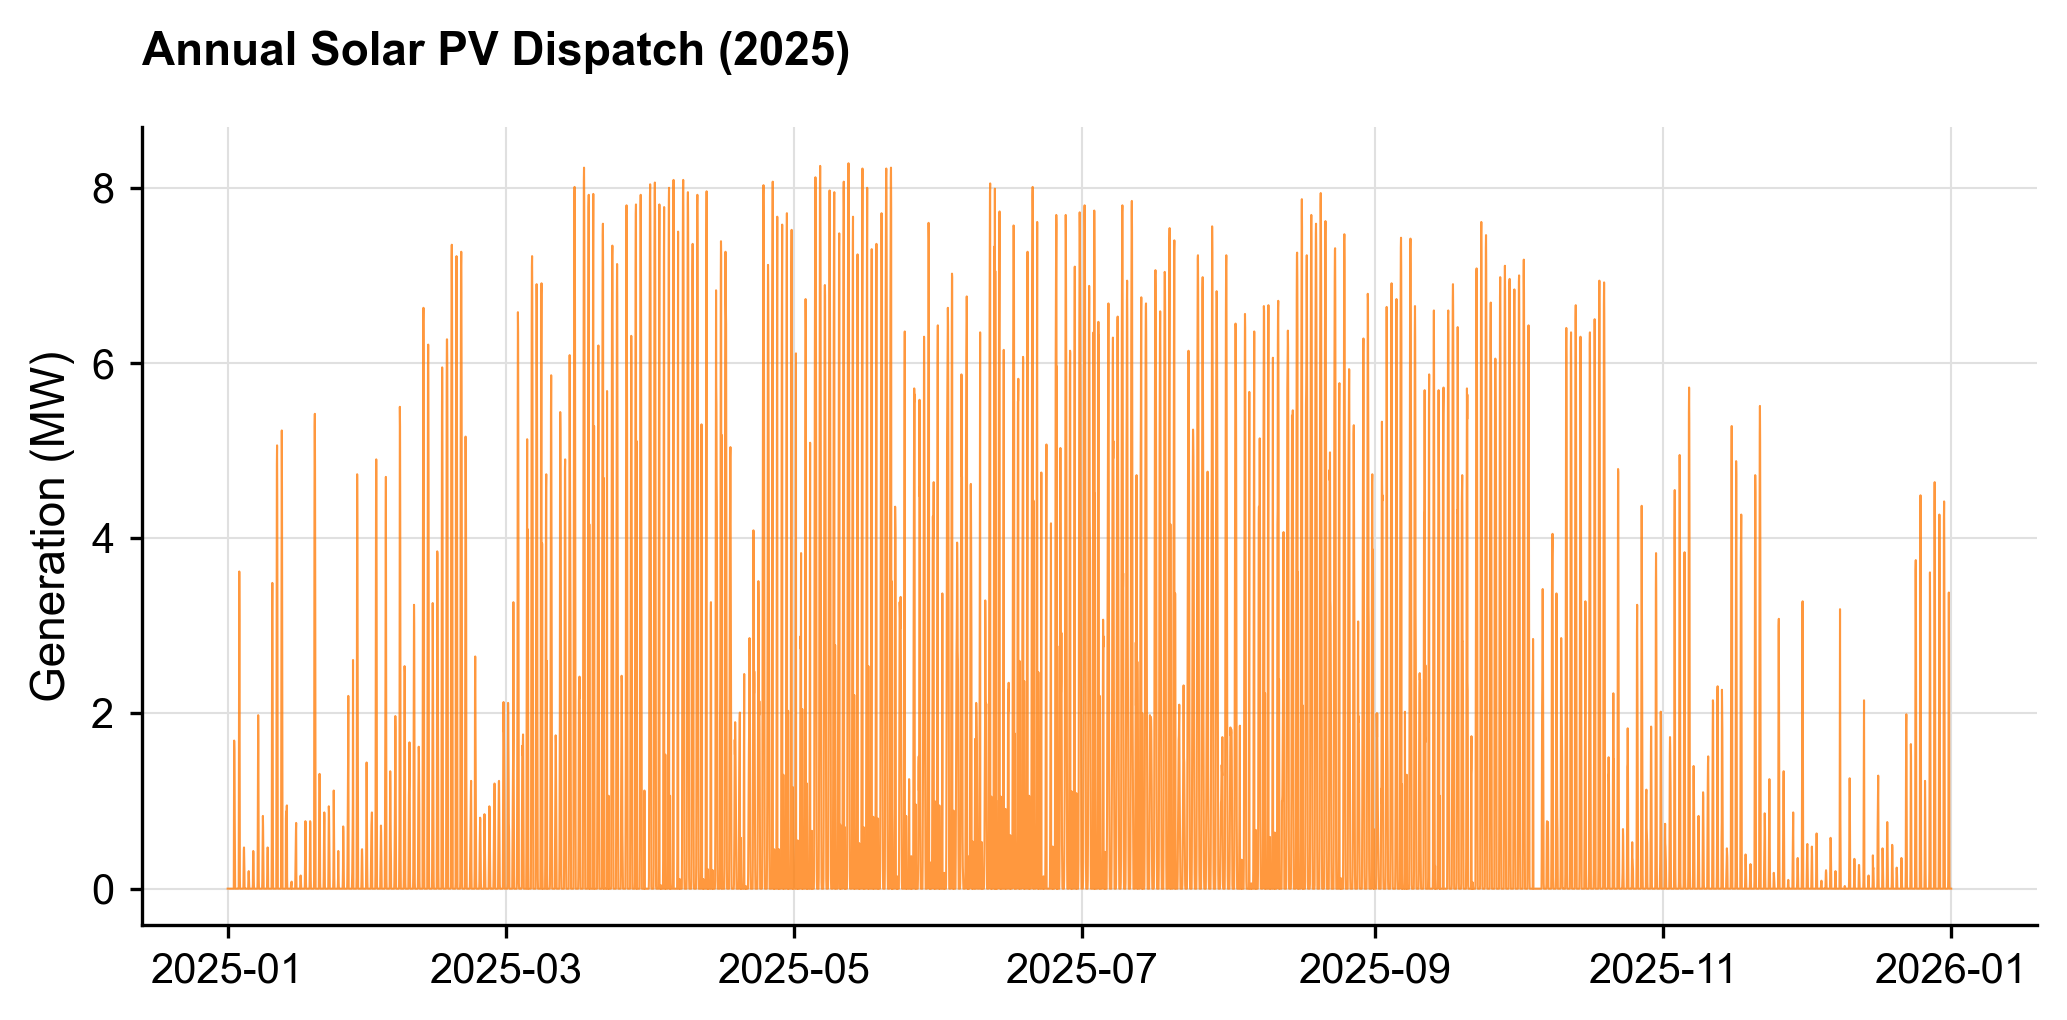

In [6]:
# Calculate Annual Totals
total_production_mwh = n.generators_t.p['Solar_PV'].sum()

# Because Grid_Export dispatch is a negative number, we multiply by -1 to show positive revenue
total_revenue_eur = (n.generators_t.p['Grid_Export'] * -1 * df_price['price']).sum()

print(f"Total Annual Solar Production: {total_production_mwh:,.2f} MWh")
print(f"Total Annual Market Revenue: €{total_revenue_eur:,.2f}")
print("-" * 40)

# Plot Annual Production Time Series
fig, ax = plt.subplots()

ax.plot(n.snapshots, n.generators_t.p['Solar_PV'], color='#ff7f0e', alpha=0.8, linewidth=0.5)

ax.set_ylabel('Generation (MW)')
ax.set_title('Annual Solar PV Dispatch (2025)', pad=15, loc='left', fontweight='bold')

plt.tight_layout()
plt.show()